## Assignment 1: Build a Toy Llama-2 Language Model

> CISC7021-2 Applied Natural Language Processing (2026/2027)

In this assignment, we will prepare a toy language model that employs the **Llama-2** architecture and evaluate the perplexity of the data set.

We will learn how to perform continual pre-training of a base language model using the PyTorch and Hugging Face libraries. Detailed instructions for building this language model can be found in the attached notebook file.

Acknowledgement: The base model checkpoint is converted from [llama2.c](https://github.com/karpathy/llama2.c) project. The data instances were sampled from [TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories) dataset.

---

🚨 Please note that running this on CPU may be slow. If running on Google Colab or Kaggle, you can avoid this by going to **Runtime > Change runtime type > Hardware accelerator > GPU > GPU type > T4**. This should be included within the free tier of Colab.

---

We start by doing a `pip install` of all required libraries.
- 🤗 `transformers`, `datasets`, `accelerate` are Huggingface libraries.
- By default, Colab has `transformers`, `pytorch` libraries installed. If you are using a local machine, please install them via `pip` or `conda`.

In [1]:
#!pip install torch torchvision torchaudio
#!pip install transformers

In [2]:
!pip install datasets accelerate -q


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### (Optional) Uploading the model/data to Google Colab or Kaggle.

Please upload your dataset and model to computational platforms if you are using Colab or Kaggle environments.

For Colab users, you can mount your Google Drive files by running the following code snippet:

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


### Necessary Packages, Environment Setups

In [3]:
import torch
import transformers

from typing import List, Optional, Tuple, Union
from transformers import LlamaForCausalLM, LlamaTokenizer, AutoTokenizer
from transformers import Trainer, TrainingArguments
from itertools import chain
from datasets import load_dataset

from tqdm.notebook import tqdm
from torch.nn import CrossEntropyLoss

Please set the correct file path based on your environment.

- If you are using Colab, the path may be: `/content/drive/MyDrive/xxxxxx`
- If you are using Kaggle, the path may be: `/kaggle/input/xxxxxx`

In [4]:
# Please set the correct file path based on your environment.
TRAIN_FILE = 'ModelAndDatasets/data/zh_train.jsonl'
VALIDATION_FILE = 'ModelAndDatasets/data/zh_dev.jsonl'
TEST_FILE = 'ModelAndDatasets/zh_test.jsonl'
EN_TEST_FILE = 'ModelAndDatasets/en_test.jsonl'
MODEL_FOLDER = "ModelAndDatasets/llama-42m"

Load the model checkpoint into either a GPU or CPU (training will be slow on CPU, but decoding will be fair).

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device type: {device}")

model_path = MODEL_FOLDER
# Load model from local files
model = LlamaForCausalLM.from_pretrained(model_path).to(device)
# Load tokenizer from local files
tokenizer = AutoTokenizer.from_pretrained(model_path, device=device)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

Device type: cuda


Loading weights:   0%|          | 0/75 [00:00<?, ?it/s]

As we can see from the statistics, this model is much smaller than Llama-2 but shares the same decoder-only architecture.


😄 **You do not need to check complex details!** We just present the architecture and number of parameters here.

In [6]:
total_para = sum(v.numel() for k, v in model.state_dict().items() if k != 'model.embed_tokens.weight') / 1e6
print(model)
print(f"#Parameters: {total_para:.2f}M")

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 512)
    (layers): ModuleList(
      (0-7): 8 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=512, out_features=512, bias=False)
          (k_proj): Linear(in_features=512, out_features=512, bias=False)
          (v_proj): Linear(in_features=512, out_features=512, bias=False)
          (o_proj): Linear(in_features=512, out_features=512, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=512, out_features=1376, bias=False)
          (up_proj): Linear(in_features=512, out_features=1376, bias=False)
          (down_proj): Linear(in_features=1376, out_features=512, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((512,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((512,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((512,), eps=1e-05)
    (rotary_emb): Llama

### Task 1: Decoding


If you are familar with the usage of `model.generate()` function in transformer library, please feel free to jump to [Task 1 Playground](#scrollTo=Task_1_Playground).


#### 💡Tutorials: model.generate() function.
---
Minimal example:

```python
prompt = "Once upon a time, " # Input, prefix of generation
```

**Step 1**: Encode raw text using tokenizer model.
```python
tokenized_input = tokenizer.encode(prompt, return_tensors='pt').to(device)
```

**Step 2**: Set decoding hyper-parameters. Get the model output.
```python
output_ids = model.generate(tokenized_input, do_sample=True, max_new_tokens=300, temperature=0.6)
```
Important parameters:
- `max_new_tokens`: The maximum numbers of tokens to generate, ignoring the number of tokens in the prompt.
- `temperature`: The value of temperature used to modulate the next token probabilities. Higher temperature -> generate more diverse text. Lower temperature -> generate more deterministic text.
- `do_sample`: `do_sample=False` is using greedy decoing strategy. To enable greedy decoding, we also need to set other sampling parameters `top_p`, `temperature` as `None`.
- [If you are interested in other decoding algorithms, please refer to this link for setting parameters.](https://huggingface.co/docs/transformers/v4.44.2/en/main_classes/text_generation#transformers.GenerationConfig)

**Step 3**: Convert model outputs into raw text.
```python
output_text = tokenizer.decode(output_ids[0])
```
or (when input instances >=1)
```python
output_text = tokenizer.batch_decode(output_ids)
```
Important parameters:
- Setting `skip_special_tokens=True` will prevent special tokens, such as `<s>`, from appearing in the results..

---


To understand the outputs of each step, let us do a simple generation task step by step! (Note: the base model is only able to produce fluent story text).

In [7]:
prompt = "There is a little kid Tony" # Feel free to use other generation prefix

In [8]:
# Step 1: Encode raw text using tokenizer model. Run tokenization and covert strings into token ids in vocabulary.
tokenized_input = tokenizer.encode(prompt, return_tensors='pt').to(device)
# See the tokenized results.
print(tokenized_input)

tensor([[    1,  1670,   338,   263,  2217, 26397, 15293]], device='cuda:0')


In [9]:
# Step 2: Set decoding hyperparameters.

# For greedy decoding
max_new_tokens = 300
do_sample = False  # `do_sample=False` means using greedy decoing strategy. To enable greedy decoding, we also need to set `top_p`, `temperature` as `None`.
temperature = None

# call generation function model.generate()
output_ids = model.generate(
    tokenized_input,
    max_new_tokens=max_new_tokens,
    eos_token_id=1,
    do_sample=do_sample,
    temperature=temperature,
    top_p=None,
)

# The decoded results are token ids.
print("=" * 20 + "Token IDs" + "=" * 20)
print(output_ids)

[transformers] Both `max_new_tokens` (=300) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


====================Token IDs====================
tensor([[    1,  1670,   338,   263,  2217, 26397, 15293,  1058, 18012,   304,
          1708, 29889,   940,   471,  2337,   577,  9796,   322,  2989,   310,
          5864, 29889,  3118,  2462, 29892, 15293,   471,  8743,   297,   278,
         14089,   746,   540,  4446,   263,  4802, 29892,   885,   653, 11203,
         29889,   940,   471,   577,   885,  1965,   393,   540,  4687,   304,
         10901, 29889,    13,  1576, 11203,  2996, 17649,   322, 15293,   471,
           577,   885,  1965,   393,   540,  8496, 29915, 29873,  4337, 29889,
           940,   925,  8389,   727, 29892, 14586, 21435, 29889,    13, 29903,
           566,  1145,   368, 29892, 15293, 29915, 29879, 16823,  2996,  2734,
           975, 29889,  2296,  1497, 29892,   376, 10310, 29915, 29873,   367,
           885,  1965, 15293, 29889,  2193, 11203,   338,   925,   263, 19780,
         11203, 29889,   940,  2113, 29915, 29873, 21682,   366,  1213,    13,
  

In [10]:
# Step 3: Convert model outputs into raw text.
# decode token ids into tokens
print("=" * 20 + "Decoded Results" + "=" * 20)
# We only have one input instance. So we directly decode the first item of model output, i.e., `output_ids[0]`.
print(tokenizer.decode(output_ids[0], skip_special_tokens=True))

====================Decoded Results====================
There is a little kid Tony who loved to play. He was always so happy and full of energy. One day, Tony was playing in the park when he saw a big, scary dog. He was so scared that he started to cry.
The dog came closer and Tony was so scared that he couldn't move. He just stood there, trembling.
Suddenly, Tony's mom came running over. She said, "Don't be scared Tony. That dog is just a friendly dog. He won't hurt you."
Tony looked up and saw that his mom was right. He slowly stepped closer and the dog wagged his tail. Tony smiled and the dog licked his hand.
Tony was so happy that he started to laugh. He said, "I'm not scared anymore!"
His mom smiled and said, "See, I told you that you wouldn't be scared." Tony hugged his mom and they both laughed.


#### Another pipeline example: Sampling decoding with temperature.

In [11]:
prompt = "There is a little kid Tony"

# Decoding hyperparameters
max_new_tokens = 300
do_sample = True
# The value of temperature used to modulate the next token probabilities.
# Higher temperature -> generate more diverse text. Lower temperature -> generate more deterministic text.
temperature = 0.8

tokenized_input = tokenizer.encode(prompt, return_tensors="pt").to(device)
output_ids = model.generate(
    tokenized_input,
    max_new_tokens=max_new_tokens,
    eos_token_id=1,
    do_sample=do_sample,
    temperature=temperature,
)
output_text = tokenizer.decode(output_ids[0])
print(output_text)


[transformers] Both `max_new_tokens` (=300) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<s> There is a little kid Tony who wanted to play. He saw his friend, Sam, walking by and he decided to follow him. He saw Sam playing in the park, and he started running after him. He ran and ran, but he couldn't catch up.
Then he saw a big pile of coal on the ground. He stopped and he thought it was so cool! He started to dig and he made little piles of coal. He kept digging until he had a big pile of coal.
Suddenly, he heard a noise and he turned around. Sam had seen him and he was so surprised! Tony said, "Let's play a game! I'll hide the coal and you have to find it!" Sam was so excited! He started looking for the coal.
He looked in the bushes, behind the trees, and under the benches. But he couldn't find it anywhere! He was so surprised and he started to get a little bit scared. But then he remembered the pile of coal! He ran over to it and he was so happy to find it!
But then he realized that the coal was all gone. He was so sad and he started to cry. He didn't know what to do. 

#### Task 1 Playground

---

📚 Task 1: Please generate English stories using various prompts and decoding settings. Please feel free to explore any interesting phenomena, such as the impact of different prompts and the effects of various decoding algorithms and parameters. For example, quantify the text properties using linguistic-driven metrics like story length and Type-Token Ratio (TTR). In addition to objective metrics, you are encouraged to discuss your findings based on subjective case studies.

We provide two types of skeleton code: one that takes a single prompt as input and another that can process batched inputs and decoding. Please use the version that best fits your preferences and data types.

---

In [12]:
# Skeleton Code: Single input (same as previous code blocks)

prompt = "" # ⬅️ try to construct different prompts.

# ⬇️ Try to tune different decoding hyperparameters.
# You can also add more hyperparameters like `top_p`, `top_k`.
max_new_tokens = 300
do_sample = True
temperature = 0.3

tokenized_input = tokenizer.encode(prompt, return_tensors="pt").to(device)
output_ids = model.generate(
    tokenized_input,
    max_new_tokens=max_new_tokens,
    eos_token_id=1,
    do_sample=do_sample,
    temperature=temperature,
)
output_text = tokenizer.decode(output_ids[0])
print(output_text)

[transformers] Both `max_new_tokens` (=300) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


<s> Once upon a time, there was a little girl named Lily. She loved to play outside in the sunshine. One day, she found a shiny rock on the ground. She picked it up and showed it to her mom.
"Look, Mommy! I found a pretty rock!" Lily said.
Her mom smiled and said, "That's a very nice rock, Lily. But be careful, it might be sharp."
Lily looked at the rock and saw that it had a pointy edge. She was careful not to touch it. Later that day, Lily's mom made some spicy chili for dinner. Lily tried it and said, "This chili is too spicy for me!"
Her mom laughed and said, "That's okay, Lily. You don't have to eat it if you don't like it."
Lily smiled and went back outside to play. She was happy to have found a pretty rock and to have her mom's cooking.<s>


In [25]:
import matplotlib.pyplot as plt
import string, re
from pprint import pprint

def cal_text_statistics(text):
    word_dict = {}
    # convert text into list
    avg_sent_len = cal_avg_sent_len(text)
    # need to deal with non-english characters such like russian
    words = re.findall(r'[^\W\d_]+', text.lower())
    # print(words)
    # calculate invert index and word count
    word_count = len(words)
    top_word_count = 0
    for word in words:
        if word in word_dict:
            word_dict[word] += 1
            # update top word count
            if word_dict[word] > top_word_count:
                top_word_count = word_dict[word]
        else:
            word_dict[word] = 1
    
    tri_gram = [tuple(words[i:i+3]) for i in range(len(words) - 2)]
    total_tri_gram = len(tri_gram)
    rep_tri = total_tri_gram - len(set(tri_gram))
    rep_ratio = rep_tri / total_tri_gram if total_tri_gram else 0
    # print(word_dict)
    ttr = cal_TTR(word_dict, word_count)
    result = {
        "word_count": word_count,
        "ttr": ttr,
        "avg_sent_len": avg_sent_len,
        "tri_gram_repeat_ratio": rep_ratio,
        "top_word_ratio": top_word_count / word_count
    }
    # print(result)
    return result

def cal_TTR(word_dict, word_count):
    return len(word_dict) / word_count
def cal_avg_sent_len(text):
    # split text into sentences
    text.replace("\n", " ")
    text.replace("\\", " ")
    sentences = [s.strip() for s in re.split(r'[。！？!?.]+', text) if s.strip()]
    # pprint(sentences)
    length = 0
    for s in sentences:
        w = re.findall(r'[^\W\d_]+', s.lower())
        length += len(w)
    return length / len(sentences)
# cal_text_statistics(output_text)

In [26]:
def get_output_statistics(prompts, batch_size, max_new_token = 300, temperature = 1.0, top_k = None, top_p = 1.0, do_sample = True):
    result_statistics = {}
    for i in range(0, len(prompts), batch_size):
        batch_input = prompts[i:i+batch_size]
        tokenized_input = tokenizer(batch_input, return_tensors="pt", padding=True).to(device)
        
        # For decoder-only models, batched inputs of model.generate() should be in the format of input_ids.
        output_ids = model.generate(
            tokenized_input["input_ids"],
            max_new_tokens=max_new_token,
            eos_token_id=1,
            do_sample=do_sample,
            temperature=temperature,
            top_p = top_p,
            top_k = top_k
        )
        output_text = tokenizer.batch_decode(output_ids, skip_special_tokens=True)
        for idx, result in enumerate(output_text):
            print(f"{result}\n")
            # put result statistics into dict
            result_statistics[i+idx] = cal_text_statistics(result)
    return result_statistics

In [27]:
import time
# Skeleton Code: Bacthed input-output

prompts = ["Once upon a time,", "Tom is a cute kitty.", "There is a little kid Tony", "Hello World", "efhiuhweiduqhvi", "1234567", "Are you happy?"]  # ⬅️ try to construct different prompts.

batch_size = 30 # If you have multiple data inputs, please control the batch size to prevent out-of-memory issues.

# ⬇️ Try to tune different decoding hyperparameters.
# You can also add more hyperparameters like `top_p`, `top_k`.
max_new_tokens = 300
do_sample = True
temperature = 0.6

overall_result = {}

max_tokens = [50, 100, 300, 500, 1000]
temperatures = [0.0001, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5, 1.8, 2.0]
top_ks = [3, 10, 50, 100, 200, 400, 500]
top_ps = [0.001, 0.2, 0.5, 0.8, 0.999]

# now let's collect some data
# my laptop is burning... oops PAGE_FATAL XD
# I really need my RTX3070 to do this XD
# My remote connection of my game laptop shot down when I am testing this section of code. Sad...
overall_result["tempretures"] = {}
overall_result["top_k"] = {}
overall_result["top_p"] = {}
overall_result["max_new_tokens"] = {}

start_time = time.perf_counter()
for t in max_tokens:
    print(f"============Max New Tokens = {t}============\n")
    result = get_output_statistics(prompts, batch_size, do_sample = True, max_new_token=t)
    overall_result["max_new_tokens"][t] = result
for t in temperatures:
    print(f"============tempreture = {t}============\n")
    result = get_output_statistics(prompts, batch_size, do_sample = True, temperature=t)
    overall_result["tempretures"][t] = result

for t in top_ks:
    print(f"============Top K = {t}============\n")
    result = get_output_statistics(prompts, batch_size, do_sample = True, top_k=t)
    overall_result["top_k"][t] = result

for t in top_ps:
    print(f"============Top p = {t}============\n")
    result = get_output_statistics(prompts, batch_size, do_sample = True, top_p=t)
    overall_result["top_p"][t] = result
# small laptop with batch size 1 to do 40 epoch takes 240 seconds
# batch size 15, 140 epoch only 38seconds
# This is RTX3070!

end_time = time.perf_counter()
total_time = end_time - start_time
print(f"inference takes: {total_time:.2f} seconds")

============Max New Tokens = 50============



[transformers] Both `max_new_tokens` (=50) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Once upon a time, and his mom were in the park. triangle trees were his favorite trees because they had images of other oats growing in them, like sunflowers and sunflowers.
Suddenly, there was a loud noise coming from up ahead

Tom is a cute kitty.ard likes to play with tubes. He makes the tubes go fast and slow, left and right. Tom also likes to chase tubes and watch them roll.
One day, Tom's mom makes a tasty

There is a little kid Tony spirged the salad from her plate to the hot red part. She felt calm and looked very happy eating her salad. But then Tony slipped and the plate flew up and dropped it on the floor.
Noisy! Every

Hello World started pouring. Every time the little hand equal from papa he poured, the water splashed on his face. Papa was very successful, with a drum in hand, and Aailitoriding in the other. He knew what he was doing

efhiuhweiduqhvi liczo his toe hurt.
He sat on the bench in pain and looked around, but he couldn't see anyone he knew. Suddenly, he heard a 

[transformers] Both `max_new_tokens` (=300) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Once upon a time,.' His name was Jazzy. He was a very honest boy of three.
One day, decrease the copper in his building painted a blue sky.anted to see the difference, but Bird seen him.
Squawkfilved nearby, "Jazzy, did you pick me up? I'm frightened!"
Jazzy smiled and said, "Not yet, practice."
The next day, fewer seasons later, and its season turned blue.
S

Tom is a cute kitty.ar means cute and he likes to play. He has a ball, a mouse and a soft bed. He likes to chase them and catch them. He feels happy when he plays.
One day, Tom sees a big bird in the yard. It is red and yellow and blue. It is a very pretty bird. Tom wants to play with it. He runs to the bird and says, "Hello, bird. Can I play with you?"
The bird looks at

There is a little kid Tony1. He was three years old and loved to play. One day Tonysvg2 wanted to climb a big mountain. He asked his mom, "Can I climb the mountain?"
His mom smiled and said, "No, Tony Morgan1, it's too high for you." 
But Tony masses1 was determ

...

Once upon a time, was a very special girl. She was very creative and loved to make things. One day, she decided to make a special surprise for her family. She worked very hard and made a beautiful card.
When her family saw the card, they were so happy. They hugged and kissed her and said, "We love you so much!"
But then, one of her family members said, "I don't want this card. It's too special."
The creative girl was very sad. She didn't know what to do. She wanted to make her family happy, but she didn't know how.
Then, she had an idea. She said, "I can make a special card for you too!"
Her family was so happy. They said, "That's so creative! Let's make a special card together!"
So, the creative girl and her family made a special card for each other. They were so happy and hugged each other. They all said, "We love you!"

Tom is a cute kitty. means a nice person who helps you. Tom likes to play with his toys and chase his tail. He also likes to eat his food and drink his milk.
One day

[transformers] Both `max_new_tokens` (=300) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Once upon a time, was a very special bird. He had a unique feather that was different from all the other birds. Every day, he would fly around the sky and make all the other birds laugh.
One day, he saw a little girl who was very sad. He flew down to her and asked her why she was sad. She said that she had lost her favourite toy.
"Don't worry," saidдол Oktober. "I will help you find it!"
The little girl smiled and said, "Thank you,¯�!"
So, dus부 flew around the sky and looked for the toy. After a while, he found it! He flew back to the little girl and she was so happy.
"Thank you,atisfied causa Ap ,," she said.
Jaatus was very happy to help. He flew away, happy that he had been able to make the little girl smile.

Tom is a cute kitty. is a small and furry animal with black and white fur. He likes to play with his ball and his mouse. He also likes to chase his tail and catch his breath.
One day, Tom sees a big box in the living room. He is curious and wants to see what is inside. He runs

[transformers] Both `max_new_tokens` (=300) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Once upon a time,. He was so happy and he loved to look at the moon. But one day, the moon was gone!fm combat autresluss was very sad and he began to weep. He was so worried and he didn't know what to do. 
He searched everywhere for the moon but it was nowhere to be seen. Then, suddenly, a bright light appeared. It was the moon! The moon said, "Don't weep Prim bog ingenrique., the only way we can be happy". 
 Answersay England was very happy and he jumped with joy. He looked at the moon and he smiled. The moon smiled back at him.async efter gau ATlach and the moon said, "Let's be friends forever!" 
And so, да FB and the moon became the best of friends and they stayed together for many days. The moon was always happy and made sure his friend slept peacefully every night.
THE

Tom is a cute kitty.'s name is Spot. He lives with Sam and Mia. Sam and Mia are Tom and Sam. They love Spot very much.
One day, Tom and Sam go to the park. They see a big dog. The dog is black and furry. He has a c

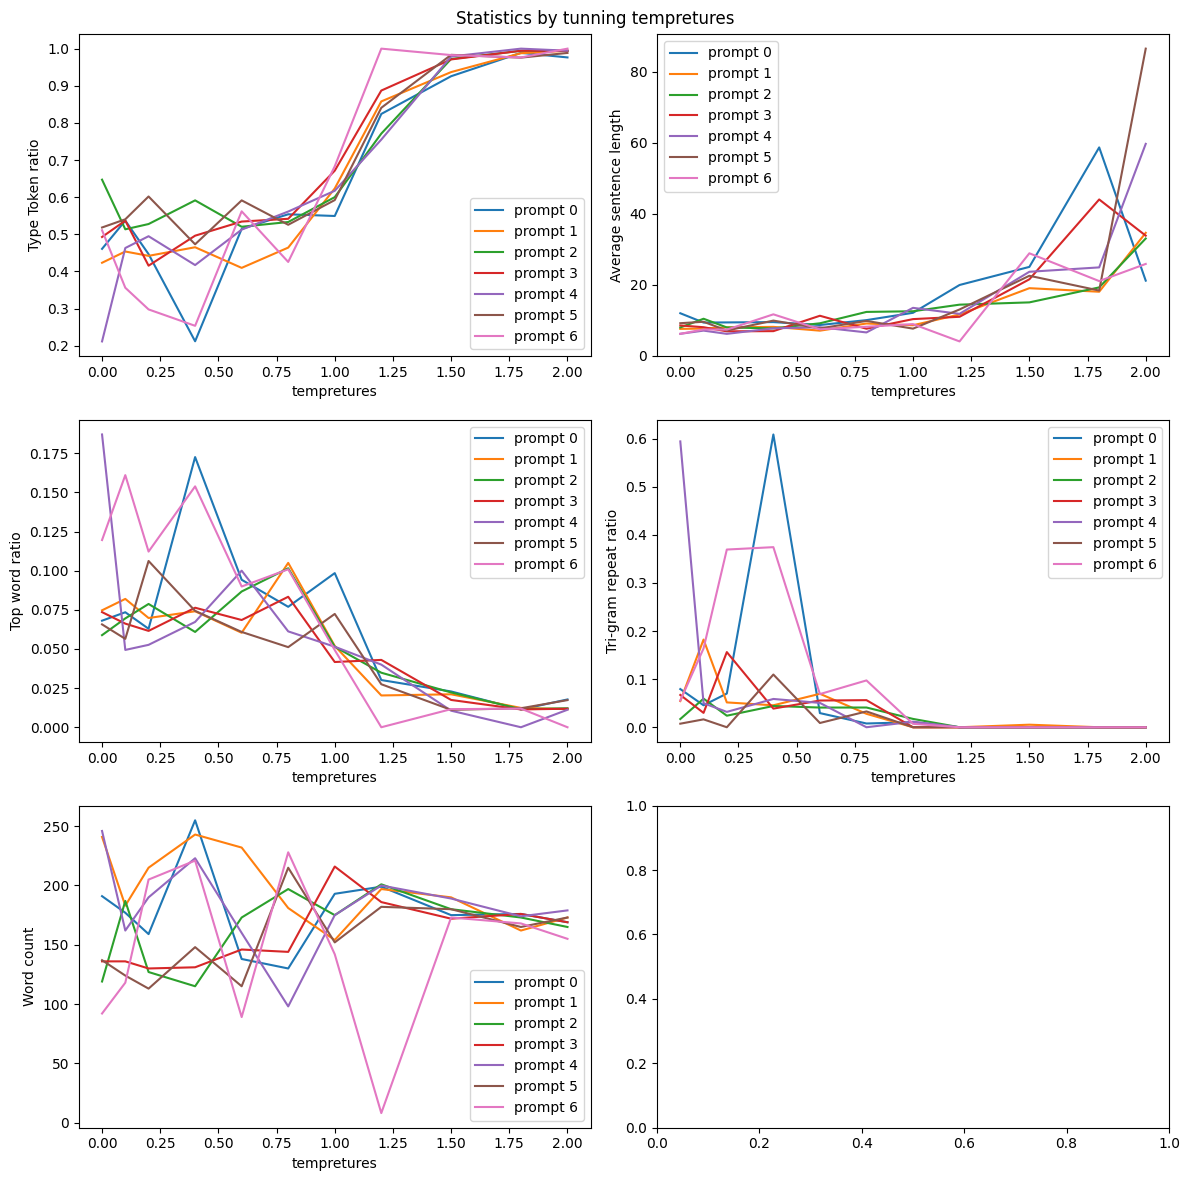

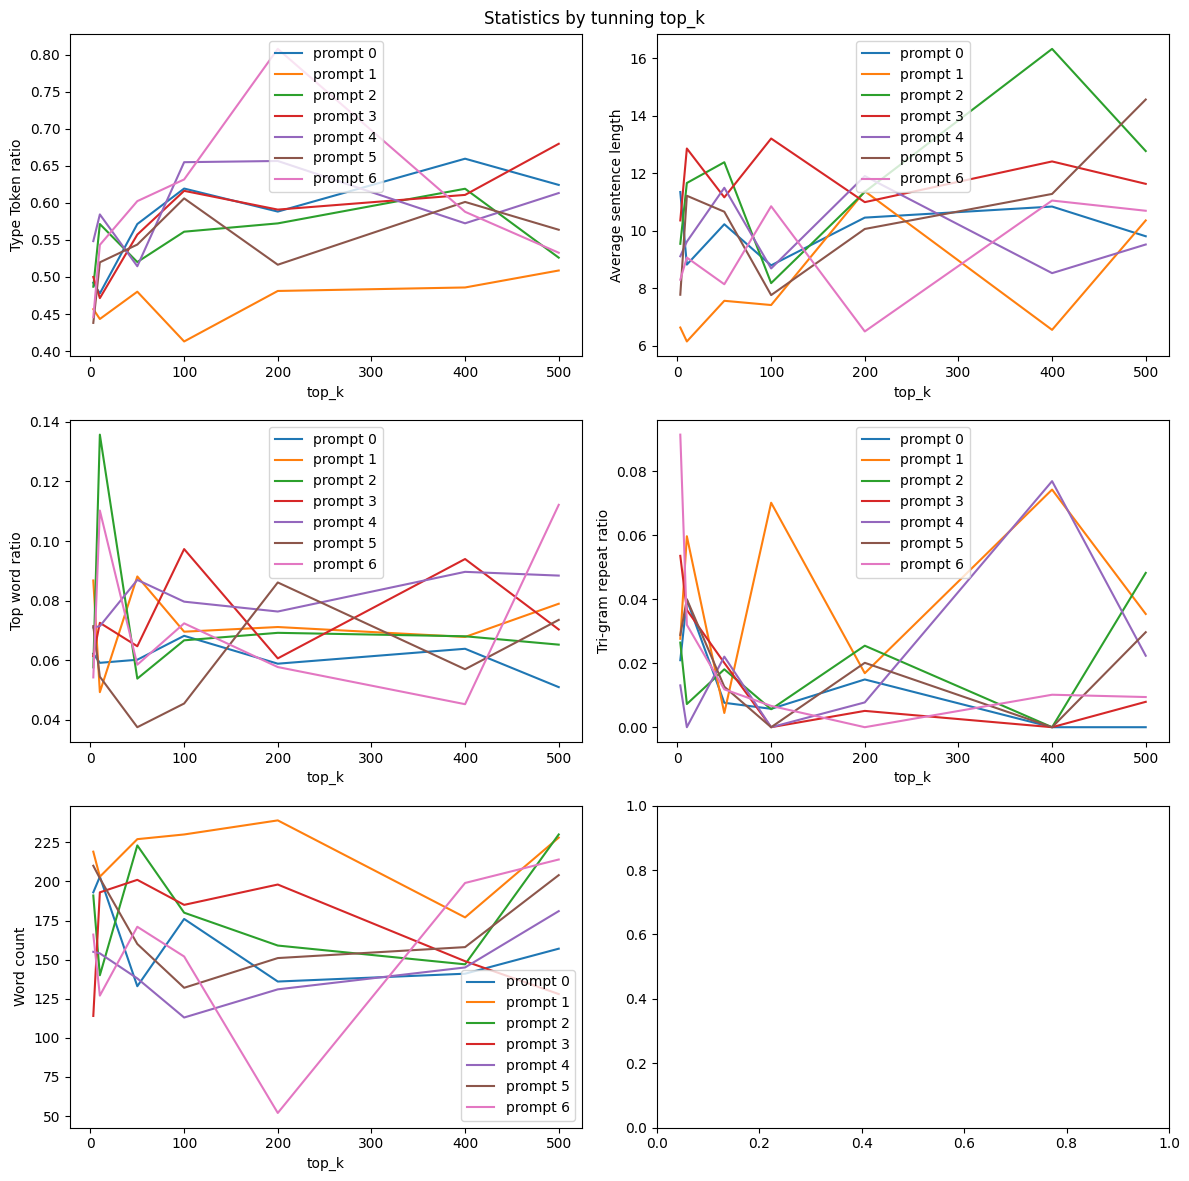

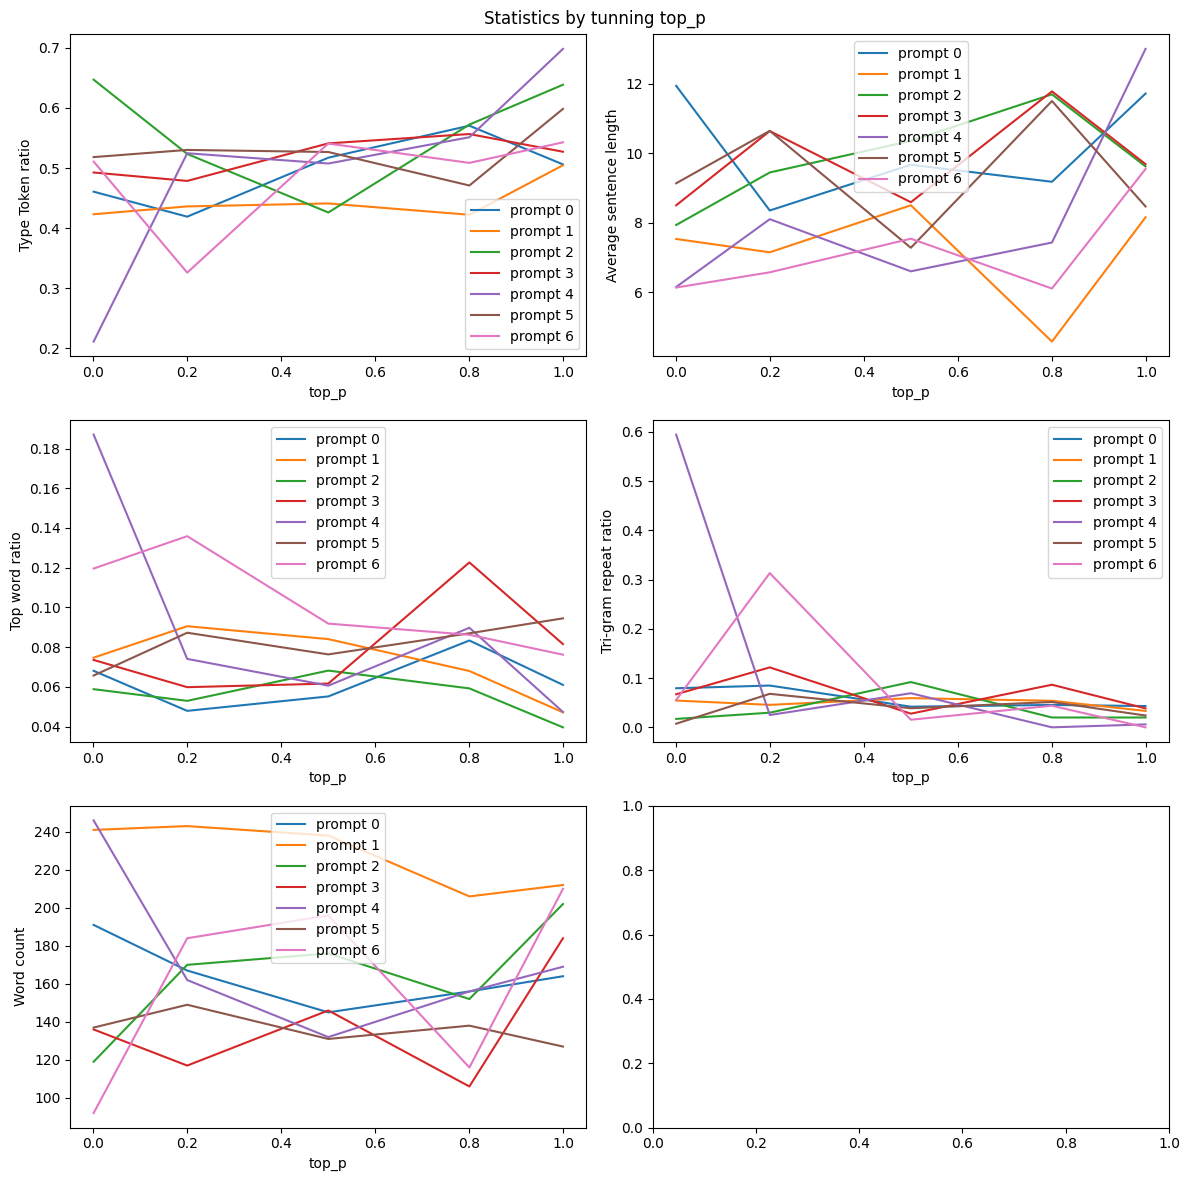

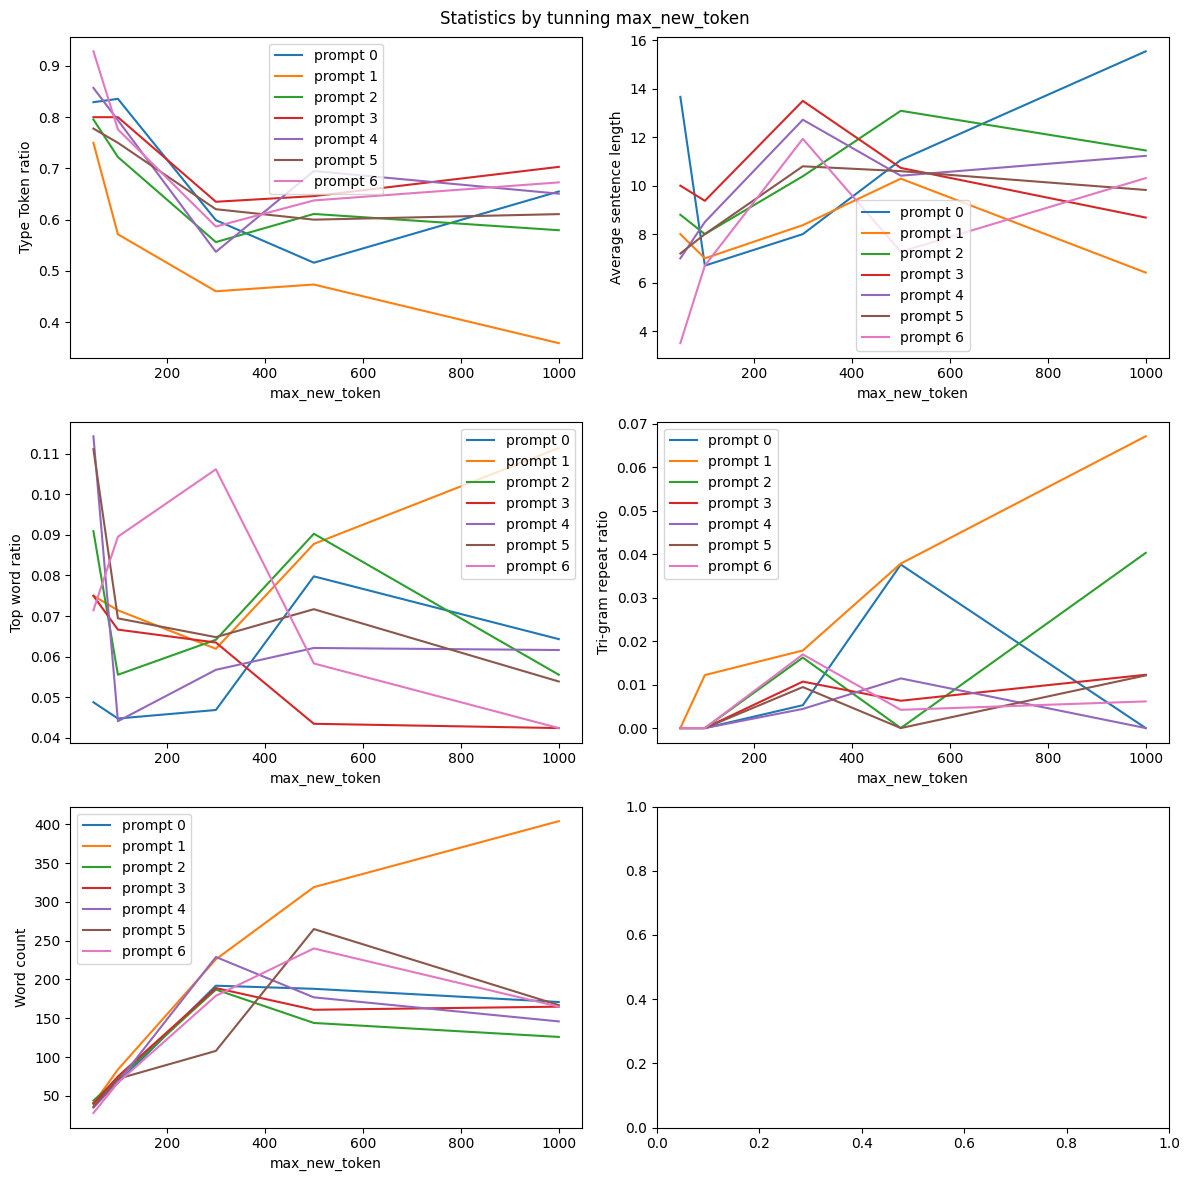

In [33]:
# statistic is a list of result_statistics
# x is the hyper-parameters list
def get_plot_group(statistic, x, name):
    # length should be len(statistic)
    fig, axes = plt.subplots(3,2, figsize=(12,12))
    # 循环顺序反了，应该是循环0-6在外
    # 这里引用了prompt的长度，是源自早期收集数据的时候的设计问题，我懒得改了，能跑就行
    # 工程角度来讲这让我很难受，但是毕竟是跑AI XD
    # 我没有那么多时间优化代码了，耦合就耦合吧 XD
    for i in range(0, len(prompts)):
        avg_sent_len_list = []
        top_word_ratio_list = []
        tri_gram_list = []
        ttr_list = []
        word_count_list = []
        for result_index in statistic:
            temp = statistic[result_index]
            ttr_list.append(temp[i]["ttr"])
            avg_sent_len_list.append(temp[i]["avg_sent_len"])
            top_word_ratio_list.append(temp[i]["top_word_ratio"])
            tri_gram_list.append(temp[i]["tri_gram_repeat_ratio"])
            word_count_list.append(temp[i]["word_count"])
        axes[0,0].plot(x, ttr_list, label=f"prompt {i}")
        axes[0,1].plot(x, avg_sent_len_list, label=f"prompt {i}")
        axes[1,0].plot(x, top_word_ratio_list, label=f"prompt {i}")
        axes[1,1].plot(x, tri_gram_list, label=f"prompt {i}")
        axes[2,0].plot(x, word_count_list, label=f"prompt {i}")

    axes[0,0].set_xlabel(name)
    axes[0,1].set_xlabel(name)
    axes[1,0].set_xlabel(name)
    axes[1,1].set_xlabel(name)
    axes[2,0].set_xlabel(name)
    axes[0,0].set_ylabel("Type Token ratio")
    axes[1,0].set_ylabel("Top word ratio")
    axes[0,1].set_ylabel("Average sentence length")
    axes[1,1].set_ylabel("Tri-gram repeat ratio")
    axes[2,0].set_ylabel("Word count")
    axes[0,0].legend()
    axes[0,1].legend()
    axes[1,0].legend()
    axes[1,1].legend()
    axes[2,0].legend()

    fig.suptitle(f"Statistics by tunning {name}")    
    
    plt.tight_layout()
    # export the chart
    plt.savefig(f"figs/{name}_chart.png")
    plt.show()

get_plot_group(overall_result["tempretures"], temperatures, "tempretures")
get_plot_group(overall_result["top_k"], top_ks, "top_k")
get_plot_group(overall_result["top_p"], top_ps, "top_p")
get_plot_group(overall_result["max_new_tokens"], max_tokens, "max_new_token")

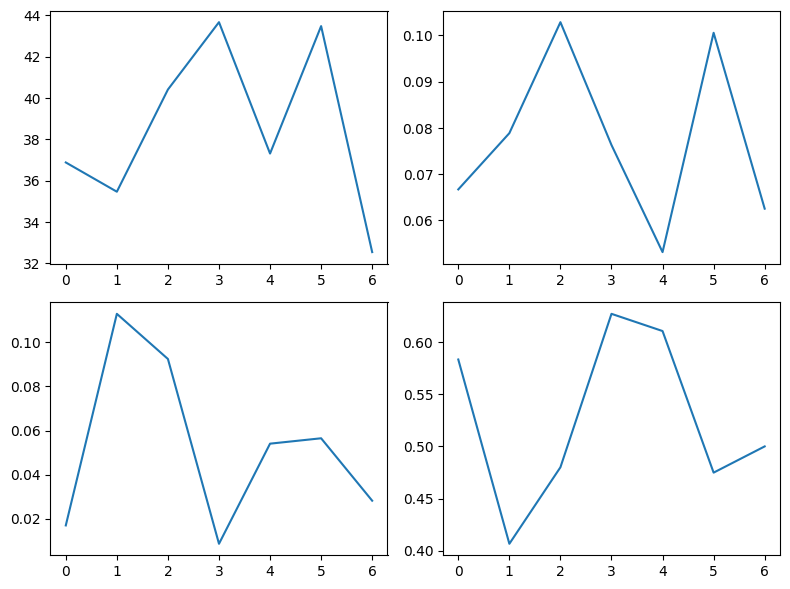

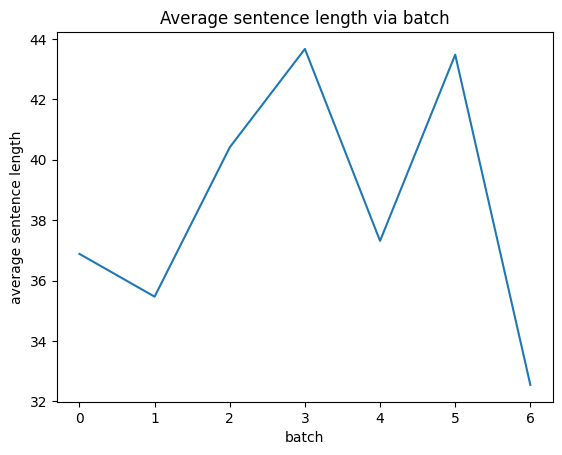

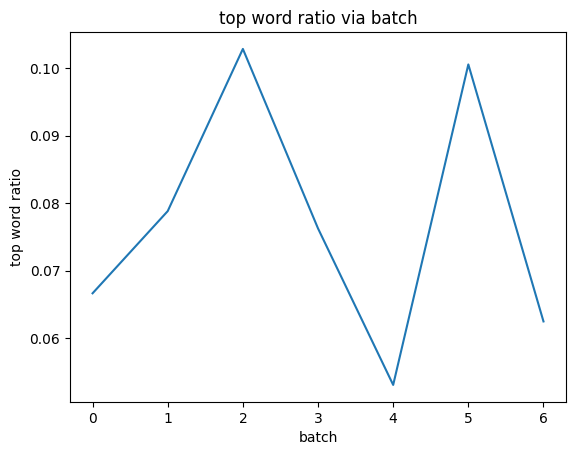

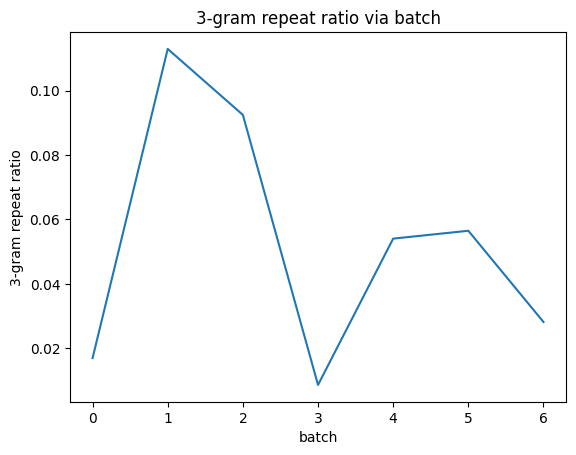

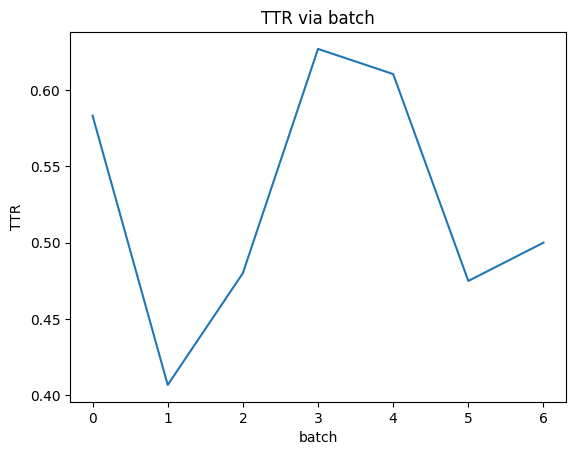

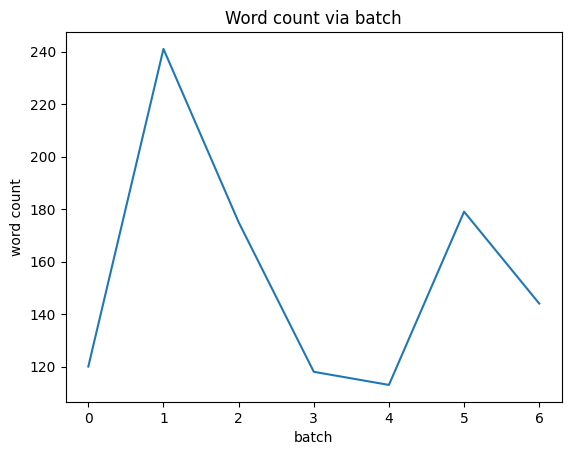

In [83]:
# Horizontal comparison
avg_sent_len_list = []
top_word_ratio_list = []
tri_gram_list = []
ttr_list = []
word_count_list = []
x = []
for k in result_statistics:
    avg_sent_len_list.append(result_statistics[k]["avg_sent_len"])
    top_word_ratio_list.append(result_statistics[k]["top_word_ratio"])
    tri_gram_list.append(result_statistics[k]["tri_gram_repeat_ratio"])
    ttr_list.append(result_statistics[k]["ttr"])
    word_count_list.append(result_statistics[k]["word_count"])
    x.append(k)

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

axes[0,0].plot(x, avg_sent_len_list)
axes[0,1].plot(x, top_word_ratio_list)
axes[1,0].plot(x, tri_gram_list)
axes[1,1].plot(x, ttr_list)
plt.tight_layout()
plt.show()

plt.plot(x, avg_sent_len_list)
plt.xlabel("batch")
plt.ylabel("average sentence length")
plt.title("Average sentence length via batch")
plt.show()

plt.plot(x, top_word_ratio_list)
plt.xlabel("batch")
plt.ylabel("top word ratio")
plt.title("top word ratio via batch")
plt.show()

plt.plot(x, tri_gram_list)
plt.xlabel("batch")
plt.ylabel("3-gram repeat ratio")
plt.title("3-gram repeat ratio via batch")
plt.show()

plt.plot(x, ttr_list)
plt.xlabel("batch")
plt.ylabel("TTR")
plt.title("TTR via batch")
plt.show()

plt.plot(x, word_count_list)
plt.xlabel("batch")
plt.ylabel("word count")
plt.title("Word count via batch")
plt.show()


#### What about other languages?

Oops! This English language model cannot generate stories in other languages!

Why? Let us evaluate the perplexity of different languages in the next task.

In [ ]:
prompt = "从前有一只小兔子乖乖"

# Decoding hyperparameters
max_new_tokens = 300
do_sample = True
temperature = 0.3

tokenized_input = tokenizer.encode(prompt, return_tensors="pt").to(device)
output_ids = model.generate(
    tokenized_input,
    max_new_tokens=max_new_tokens,
    eos_token_id=1,
    do_sample=do_sample,
    temperature=temperature,
)
output_text = tokenizer.decode(output_ids[0])
print(output_text)


<s> 从前有一只小兔子乖乖ons. They were very excited to go to the park.
When they got there, they saw a big, red slide. They ran over to it and started to slide down. They laughed and giggled as they slid down.
When they got to the bottom, they saw a big, blue ball. They both wanted to play with it.
"Let's play with the ball," said Sammy.
"No, let's play with the ball," said Mommy.
They argued for a while, but then Mommy had an idea.
"Why don't we take turns? You can play with the ball first, and then Sammy can play with it."
Sammy and Mommy agreed. Sammy played with the ball first, then Mommy played with the ball. Sammy had lots of fun.
When it was Sammy's turn, he was so excited. He ran over to the ball and started to play with it. Mommy watched him and smiled.
"That's a good idea Sammy," said Mommy. "It's important to share and take turns."
Sammy nodded and smiled. He was happy that Mommy was so understanding.<s>


### Task 2: Perplexity Evaluation

#### Background

---

The perplexity serves as a key metric for evaluating language models. It quantifies how well a model predicts a sample, with lower perplexity indicating better performance. For a tokenized sequence $X = (x_0, x_1, \dots, x_t)$, the perplexity is defined mathematically as:

$$\text{Perplexity}(X) = \exp \left( -\frac{1}{t} \sum_{i=1}^t \log p_\theta (x_i | x_{<i}) \right)$$

Here, $p_\theta(x_i | x_{<i})$ represents the probability of a token $ x_i $ given its preceding tokens, and the formulation incorporates the average log probability across the sequence.

---

⚠️ Please make sure to **run the following cell first** to define the evaluation function.

😄 **You do not need to check these complex details! Too hard for beginners!** However, if you are interested, you can compare the following code with the explanations above to better understand how to implement PPL evaluation using PyTorch.

In [ ]:
# The following code was adapted from the `evaluate` library. Licensed under the Apache License, Version 2.0 (the "License").
# We modify them to avoid causing serious memory issues in the Colab environment.

def compute_ppl(
        model, tokenizer, inputs, device, batch_size: int = 16, add_start_token: bool = True, max_length=None
):

    if device is not None:
        assert device in ["gpu", "cpu", "cuda"], "device should be either gpu or cpu."
        if device == "gpu":
            device = "cuda"
    else:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # if batch_size > 1 (which generally leads to padding being required), and
    # if there is not an already assigned pad_token, assign an existing
    # special token to also be the padding token
    if tokenizer.pad_token is None and batch_size > 1:
        existing_special_tokens = list(tokenizer.special_tokens_map_extended.values())
        # check that the model already has at least one special token defined
        assert (
            len(existing_special_tokens) > 0
        ), "If batch_size > 1, model must have at least one special token to use for padding. Please use a different model or set batch_size=1."
        # assign one of the special tokens to also be the pad token
        tokenizer.add_special_tokens({"pad_token": existing_special_tokens[0]})

    if add_start_token and max_length:
        # leave room for <BOS> token to be added:
        assert (
            tokenizer.bos_token is not None
        ), "Input model must already have a BOS token if using add_start_token=True. Please use a different model, or set add_start_token=False"
        max_tokenized_len = max_length - 1
    else:
        max_tokenized_len = max_length

    encodings = tokenizer(
        inputs,
        add_special_tokens=False,
        padding=True,
        truncation=True if max_tokenized_len else False,
        max_length=max_tokenized_len,
        return_tensors="pt",
        return_attention_mask=True,
    )

    encoded_texts = encodings["input_ids"]
    attn_masks = encodings["attention_mask"]

    # check that each input is long enough:
    if add_start_token:
        assert torch.all(torch.ge(attn_masks.sum(1), 1)), "Each input text must be at least one token long."
    else:
        assert torch.all(
            torch.ge(attn_masks.sum(1), 2)
        ), "When add_start_token=False, each input text must be at least two tokens long. Run with add_start_token=True if inputting strings of only one token, and remove all empty input strings."

    ppls = []
    loss_fct = CrossEntropyLoss(reduction="none")

    for start_index in tqdm(range(0, len(encoded_texts), batch_size)):
        end_index = min(start_index + batch_size, len(encoded_texts))
        encoded_batch = encoded_texts[start_index:end_index].to(device)
        attn_mask = attn_masks[start_index:end_index].to(device)

        if add_start_token:
            bos_tokens_tensor = torch.tensor([[tokenizer.bos_token_id]] * encoded_batch.size(dim=0)).to(device)
            encoded_batch = torch.cat([bos_tokens_tensor, encoded_batch], dim=1)
            attn_mask = torch.cat(
                [torch.ones(bos_tokens_tensor.size(), dtype=torch.int64).to(device), attn_mask], dim=1
            )

        labels = encoded_batch

        with torch.no_grad():
            out_logits = model(encoded_batch, attention_mask=attn_mask).logits

            shift_logits = out_logits[..., :-1, :].contiguous()
            shift_labels = labels[..., 1:].contiguous()
            shift_attention_mask_batch = attn_mask[..., 1:].contiguous()

            perplexity_batch = torch.exp(
                (loss_fct(shift_logits.transpose(1, 2), shift_labels) * shift_attention_mask_batch).sum(1)
                / shift_attention_mask_batch.sum(1)
            )

            ppls += perplexity_batch.tolist()

    del encoded_batch, attn_mask
    if device == "cuda":
        torch.cuda.empty_cache()

    return {"perplexities": ppls, "mean_perplexity": sum(ppls)/float(len(ppls))}


#### 💡Tutorials: compute_ppl() function.

---
Minimal example:

```python
test_dataset = ["Once upon a time,"]

compute_ppl(
    model=model,
    tokenizer=tokenizer,
    device=device,
    inputs=test_dataset,
    batch_size = 16
)
```

Important parameters:
- `inputs`: list of input text, each separate text snippet is one list entry.
- `batch_size`: the batch size to run evaluations.

Returns:
- `perplexity`: `{"perplexities": [x.x, x.x, ...], "mean_perplexity": x.x}` dictionary containing the perplexity scores for the texts in the input list, as well as the mean perplexity. .


---

#### Task 2 Playground

---

📚 Task 2: Evaluate the perplexity. Ensure that you evaluate both the English and Chinese test data we provided. You are encouraged to collect more diverse text data and discuss your findings regarding the language understanding capacity of the base model.


Note: If you want to reuse the evaluation codes for JSONL data, please structure the content as follows:
```json
{"text": "one data"}
{"text": "two data."}
...
```
**You may find that the PPL value for Chinese text is significantly higher than that for English text. This is evidence that the base model cannot generate a Chinese story at the end of the last task.**

---

In [ ]:
# Skeleton Code: Evaluate the perplexity (PPL) on a list of raw text.

test_dataset = ["Once upon a time,", "Tom is a cute kitty."] # ⬅️ you can use your examples / or read from raw text file

results = compute_ppl(model=model, tokenizer=tokenizer, device=device, inputs=test_dataset, batch_size = 16)
dataset_ppl = results['mean_perplexity']
print(f"Perplexity: {dataset_ppl:.2f}")

  0%|          | 0/1 [00:00<?, ?it/s]

Perplexity: 10.68


In [ ]:
# Skeleton Code: Evaluate the perplexity (PPL) on an external test set file (JSONL).

# English test set.
data_file = EN_TEST_FILE # ⬅️ you can change your file path
test_dataset = load_dataset('json', data_files={'test': data_file})["test"]["text"]

results = compute_ppl(model=model, tokenizer=tokenizer, device=device, inputs=test_dataset, batch_size = 16)
dataset_ppl = results['mean_perplexity']
print(f"(English Text) Test Perplexity: {dataset_ppl:.2f}")

# Chinese test set.
data_file = TEST_FILE # ⬅️ you can change your file path
test_dataset = load_dataset('json', data_files={'test': data_file})["test"]["text"]

results = compute_ppl(model=model, tokenizer=tokenizer, device=device, inputs=test_dataset, batch_size = 16)
dataset_ppl = results['mean_perplexity']
print(f"(Chinese Text) Test Perplexity: {dataset_ppl:.2f}")


# Try your own data file!

  0%|          | 0/63 [00:00<?, ?it/s]

(English Text) Test Perplexity: 4.14


  0%|          | 0/63 [00:00<?, ?it/s]

(Chinese Text) Test Perplexity: 70030.42


In [ ]:
# 🚨 Release gpu cache before training the model
if device == "cuda":
    torch.cuda.empty_cache()

### Task 3: Continual Pre-training (in Chinese or in another language you are proficient in)

Currently, our base English LM is proficient in English but lacks the capability to generate or comprehend other languages (e.g., Chinese). The objective of this task is to enhance a base English LM by continually pre-training it with text in another language. This process aims to enable the model to understand and generate mini-story in another language.

We have provided 10,000 Chinese training samples. The training process for any language is the same. We have included useful resource links (in Assignment description PDF) to help you create additional data. If you encounter any issues in creating a dataset in another language, please do not hesitate to contact us.

We have implemented data preprocessing and the training pipeline, so you are not required to optimize these components. Instead, focus on tuning the training hyperparameters and observe the changes in model performance.


---

⚠️ Please **make sure to run the following cell first to pre-process data**.

😄 You do not need to check the details of whole pipeline construction! Please pay attention to the hyper-parameters of `trainer`.

#### Preprocess Data
Here, we preprocess (tokenize and group) the text for the subsequent evaluation and pre-training phases.

Load prepared Chinese dataset from Google drive (or local disk).

In [ ]:
chinese_dataset = load_dataset('json', data_files={'train': TRAIN_FILE, 'validation':VALIDATION_FILE, 'test': TEST_FILE})
print(chinese_dataset)
print(chinese_dataset["test"][2]["text"])

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 500
    })
    test: Dataset({
        features: ['text'],
        num_rows: 1000
    })
})
从前，有一个小女孩名叫莉莉。她喜欢和家人一起去度假。有一天，她的家人决定去海边旅行。莉莉非常兴奋，她跳起来又跳下去，像发了疯一样。

当他们到达海滩时，他们搭起了遮阳伞和毯子。莉莉想立刻去游泳，但她的父母告诉她要等吃完午餐再说。莉莉感到很不耐烦，她说：“我现在就想去游泳！”她妈妈回答：“莉莉，我们需要先吃东西。游泳需要能量。”

莉莉意识到妈妈说得对，于是耐心地等待午餐结束。她学会了有时候要克制自己的激动情绪，并听从父母的意见。从那天起，莉莉变得更善于倾听，也更加享受她的假期时光。


We tokenize the raw text using Llama-2's tokenizer and group the tokenized text as inputs.

In [ ]:
block_size = 512

def group_texts(examples):
    concatenated_examples = {k: list(chain(*examples[k])) for k in examples.keys()}
    total_length = len(concatenated_examples[list(examples.keys())[0]])
    if total_length >= block_size:
        total_length = (total_length // block_size) * block_size
    result = {
        k: [t[i : i + block_size] for i in range(0, total_length, block_size)]
        for k, t in concatenated_examples.items()
    }
    result["labels"] = result["input_ids"].copy()
    return result

In [ ]:
tokenized_zh_datasets = chinese_dataset.map(lambda examples: tokenizer(examples["text"]), batched=True, num_proc=4, remove_columns=["text"])
lm_datasets = tokenized_zh_datasets.map(
    group_texts,
    batched=True,
    batch_size=512,
    num_proc=4,
)

#### 💡Tutorials: TrainingArguments().

**Important Training Hyper-parameters**
- learning_rate: The initial learning rate for optimizer.
- num_train_epochs: Total number of training epochs to perform (if not an integer, will perform the decimal part percents of the last epoch before stopping training).
- *_strategy: The evaluation/saving strategy to adopt during training. Possible values are:
    - `"no"`: No evaluation/saving is done during training.
    - `"steps"`: Evaluation/saving is done (and logged) every `eval_steps`.
    - `"epoch"`: Evaluation/saving is done at the end of each epoch.
- per_device_train_batch_size: The batch size per GPU/XPU/TPU/MPS/NPU core/CPU for training.
- per_device_eval_batch_size: The batch size per GPU/XPU/TPU/MPS/NPU core/CPU for evaluation.
- save_total_limit: If a value is passed, will limit the total amount of checkpoints.


---

If you do not understand `AdamW` optimizer and learning scheduler, you may use default settings.

**Optimizer Hyper-parameters**
- weight_decay: The weight decay to apply (if not zero) to all layers except all bias and LayerNorm weights in [`AdamW`] optimizer.
- adam_beta1: The beta1 hyperparameter for the [`AdamW`] optimizer.
- adam_beta2: The beta2 hyperparameter for the [`AdamW`] optimizer.

**Learning schedule**
- lr_scheduler: The scheduler type to use.
- warmup_ratio: Ratio of total training steps used for a linear warmup from 0 to `learning_rate`.

[Explore more parameters here](https://huggingface.co/docs/transformers/v4.44.2/en/main_classes/trainer#transformers.TrainingArguments)

#### Task 3 Playground

---

📚 Please just run the following code to do continual pre-training. Please try your best to tune the hyperparameters or collect more data to improve model performance.

---

In [ ]:
# =========Pre-training hyperparameters, please feel free to tune them~=========
# =Important=
lr = 1e-4
epochs = 8
save_steps=200
strategy="steps"
train_bsz = 32 # reduce batch size if you encountered out-of-memory errors.
eval_bsz = 16

# If you do not understand AdamW optimizer and learning scheduler, you may use default settings.
# =Optimizer=
optimizer = "adamw_torch"
weight_decay = 0.01
adam_beta1 = 0.9
adam_beta2 = 0.98
# =Learning scheduler=
lr_scheduler = "linear"
warmup_ratio = 0.01
# =========End of pre-training hyperparameters=========


training_args = TrainingArguments(
    "llama-42m-zh-fairytales",
    evaluation_strategy = strategy,
    eval_steps=save_steps,
    save_strategy = strategy,
    save_steps=save_steps,
    logging_strategy="steps",
    logging_steps = 10,
    learning_rate=lr,
    weight_decay=weight_decay,
    seed=42,
    per_device_train_batch_size=train_bsz,
    per_device_eval_batch_size=eval_bsz,
    save_total_limit=1,
    optim = optimizer,
    lr_scheduler_type = lr_scheduler,
    adam_beta1 = adam_beta1,
    adam_beta2 = adam_beta2,
    warmup_ratio = warmup_ratio,
    num_train_epochs = epochs,
    report_to=None
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=lm_datasets["train"],
    eval_dataset=lm_datasets["validation"],
)

In [ ]:
trainer.train()

Step,Training Loss,Validation Loss
200,3.298300,3.243898
400,1.910000,1.898938
600,1.548700,1.571377
800,1.381600,1.436444
1000,1.313700,1.372024
1200,1.252300,1.322885
1400,1.179800,1.296618
1600,1.129800,1.278112
1800,1.088200,1.270051
2000,1.106700,1.262663


TrainOutput(global_step=2000, training_loss=1.7592032198905945, metrics={'train_runtime': 733.814, 'train_samples_per_second': 86.878, 'train_steps_per_second': 2.725, 'total_flos': 4956004181606400.0, 'train_loss': 1.7592032198905945, 'epoch': 8.0})

Load pre-trained model and try to generate mini-story in another language.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device type: {device}")

new_model_path = "llama-42m-zh-fairytales/checkpoint-2000" # saved checkpoint path
model = LlamaForCausalLM.from_pretrained(new_model_path).to(device)
tokenizer = AutoTokenizer.from_pretrained(model_path, device=device)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

Device type: cuda


Evaluate the PPL on Chinese text (or another language) again.

You will notice that we actually achieve a much lower PPL after continual pre-training.

In [ ]:
data_file = TEST_FILE
test_dataset = load_dataset('json', data_files={'test': data_file})["test"]["text"]

results = compute_ppl(model=model, tokenizer=tokenizer, device=device, inputs=test_dataset, batch_size = 16)
dataset_ppl = results['mean_perplexity']
print(f"Test Perplexity: {dataset_ppl:.2f}")

Validation Perplexity: 3.53
Test Perplexity: 3.52


---

The original English base model was pre-trained on 2 million data samples. Considering we are using only 10,000 training samples (0.5% of the original pre-training data), the model can generate a few fluent sentences but may still struggle with long-text generation or common sense of other languages. You can try using more data or training steps depending on your computational resources.

---

In [ ]:
prompt = "从前，有一只叫做汤姆的猫。汤姆和他的朋友们一起玩。"

# Decoding hyperparameters
max_new_tokens = 300
do_sample = True
temperature = 0.3

tokenized_input = tokenizer.encode(prompt, return_tensors="pt").to(device)
output_ids = model.generate(
    tokenized_input,
    max_new_tokens=max_new_tokens,
    eos_token_id=1,
    do_sample=do_sample,
    temperature=temperature,
)
output_text = tokenizer.decode(output_ids[0])
print(output_text)

<s> 从前，有一只叫做汤姆的猫。汤姆和他的朋友们一起玩。他们喜欢在公园里玩耍。有一天，汤姆和他的朋友们决定去公园玩。

在公园里，汤姆看到了一个大滑梯。他想玩滑梯。他跑去滑梯，但不小心掉在了地上。汤姆很伤心。

汤姆很高兴他的朋友们能帮助他。他们一起玩滑梯，度过了很多快乐时光。
